# E-Commerce Sales Data Analysis 

## Project Overview 
This project explores an e-commerce dataset to understand customer behavior, order patterns, delivery performance, product sales, and customer satisfaction.
The analysis focuses on identifying actionable business insights through Exploratory Data Analysis (EDA) using Python.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn


### 1. Import Required Libraries

In [1]:
# Libraries for data manipulation
import numpy as np
import pandas as pd

#Libraries for visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#Display settings
sns.set_style('darkgrid')


### 2. Load the Dataset

The dataset consists of multiple relational tables representing customers, orders, products, payments, reviews, sellers, and geolocation information.

In [2]:
# Reading all the files into pandas dataframes
customers= pd.read_csv('brazilian e commerce dataset/olist_customers_dataset.csv')
geolocation= pd.read_csv('brazilian e commerce dataset/olist_geolocation_dataset.csv')
order_items= pd.read_csv('brazilian e commerce dataset/olist_order_items_dataset.csv')
order_payments= pd.read_csv('brazilian e commerce dataset/olist_order_payments_dataset.csv')
order_reviews=pd.read_csv('brazilian e commerce dataset/olist_order_reviews_dataset.csv')
orders=pd.read_csv('brazilian e commerce dataset/olist_orders_dataset.csv')
products=pd.read_csv('brazilian e commerce dataset/olist_products_dataset.csv')
sellers=pd.read_csv('brazilian e commerce dataset/olist_sellers_dataset.csv')
product_category_translation=pd.read_csv('brazilian e commerce dataset/product_category_name_translation.csv')

### 3. Understanding the Data

In this section, we inspect the datasets to understand their structure, identify missing values, and become familiar with them.

In [3]:
# Store all datasets in a dictionary for easier inspection

datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "product_category_translation": product_category_translation
}

#### a. Customer Dataset

In [4]:
#Preview the dataset
customers.head()

#Check dataset dimensions
customers.shape

#Check missing values
customers.isna().sum()

#Generate basic statistics
customers.describe()

#Verifying Uniqueness of key columns
customers['customer_unique_id'].is_unique 
customers['customer_id'].is_unique 

True

#### b. Geolocation Dataset

In [5]:
#Preview the dataset
geolocation.head()

#Check dataset dimensions 
geolocation.shape 

#Check missing values
geolocation.isna().sum() 

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

#### c. Order Items Dataset

In [6]:
# Preview the dataset
order_items.head()

#Check dataset dimensions
order_items.shape

#Check missing values
order_items.isna().sum() 

#Generate basic statistsics
order_items.describe()

#Verify composite primary key
order_items.set_index(['order_id', 'order_item_id']).index.is_unique 

True

#### d. Order Payments Dataset

In [7]:
# Preview the dataset
order_payments.head()

# Check dataset dimensions
order_payments.shape

# Check missing values
order_payments.isna().sum()

# Generate basic statistics
order_payments.describe()

#Verify composite key
order_payments.set_index(['order_id', 'payment_sequential']).index.is_unique 

True

#### e. Order Reviews Dataset

In [8]:
# Preview the dataset
order_reviews.head()

#Check dataset shape 
order_reviews.shape

#Check missing values 
order_reviews.isna().sum() 

#Generate basic statistics
order_reviews.describe()

#Verify composite key
order_reviews.set_index(['review_id', 'order_id']).index.is_unique

True

#### f. Orders Dataset

In [9]:
# Preview the dataset
orders.head()

#Check dataset shape 
orders.shape 

#Check missing values 
orders.isna().sum()

#Generate basic statistics
orders.describe()

#Verify uniqueness of key column
orders['order_id'].is_unique

True

#### g. Products Dataset

In [10]:
# Preview the dataset
products.head()

#Check dataset shape 
products.shape 

#Check missing values 
products.isna().sum()

#Generate basic statistics
products.describe()

#Verify uniqueness of key column
products['product_id'].is_unique

True

#### h. Sellers Dataset

In [11]:
# Preview the dataset
sellers.head()

#Check dataset shape 
sellers.shape 

#Check missing values 
sellers.isna().sum() 

#Generate basic statistics
sellers.describe()

#Verify uniqueness of key column
sellers['seller_id'].is_unique 

True

#### i. Product Category Translation Dataset

In [12]:
# Preview the dataset
product_category_translation.head()

#Check dataset shape 
product_category_translation.shape 

#Check missing values 
product_category_translation.isna().sum() 

#Verify uniqueness of key column
product_category_translation['product_category_name'].is_unique

True

#### Dataset Summary

After inspecting each table individually, we create a consolidated summary table containing:

- Number of rows
- Number of columns
- Missing values
- Primary key
- Description

In [13]:
summary=[]
for name, df in datasets.items():
    summary.append({
        'table':name,
        'rows': df.shape[0],
        'columns': df.shape[1]
    })
summary_df=pd.DataFrame(summary)

#Adding primary keys
summary_df['primary key']=['customer_id', 'none', '(order_id, order_item_id)', '(order_id, payment_sequential)',
                          '(review_id, order_id)', 'order_id', 'product_id', 'seller_id', 'product_category_name'
                          ]

# Calculate total missing values in each dataset
missing_values=[]
for name, df in datasets.items():
    missing_values.append(df.isna().sum().sum())
summary_df['missing values']=missing_values

# Adding a short description for each dataset
summary_df['description']=[
    'customer details and location',
    'Brazilian zip codes and coordinates', 
    'products in each order and their seller',
    'payment details for each order',
    'reviews of orders', 
    'order status and delivery date', 
    'product details',
    'seller id and location', 
    'category name translation from brazilian to english'
]
summary_df


,table,rows,columns,primary key,missing values,description
0,customers,99441,5,customer_id,0,customer details and location
1,geolocation,1000163,5,none,0,Brazilian zip codes and coordinates
2,order_items,112650,7,"(order_id, order_item_id)",0,products in each order and their seller
3,order_payments,103886,5,"(order_id, payment_sequential)",0,payment details for each order
4,order_reviews,99224,7,"(review_id, order_id)",145903,reviews of orders
5,orders,99441,8,order_id,4908,order status and delivery date
6,products,32951,9,product_id,2448,product details
7,sellers,3095,4,seller_id,0,seller id and location
8,product_category_translation,71,2,product_category_name,0,category name translation from brazilian to en...


## 4. Data Cleaning
Before analysis, the following pre-processing steps were performed:
- Converted date columns to datetime format
- Checked for duplicate records
- Added English translations for product categories

#### Converting date columns to datetime format

In [14]:
date_cols=['order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date']
orders[date_cols]=orders[date_cols].apply(pd.to_datetime)

#### Check for duplicates

In [15]:
for name, df in datasets.items():
    print(f'{name}:{df.duplicated().sum()}')


customers:0
geolocation:261836
order_items:0
order_payments:0
order_reviews:0
orders:0
products:0
sellers:0
product_category_translation:0


#### Translating Product Categories

In [16]:
products=products.merge(product_category_translation, on='product_category_name', how='left')
products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


## 5. Feature Engineering
To simplify time-based analysis and delivery performance evaluation, several new variables were created from the existing data.

#### Purchase Date Features

In [17]:
#Extracting year, month, day etc from the order purchase timestamp column 
orders['purchase_year']=orders['order_purchase_timestamp'].dt.year
orders['purchase_month']= orders['order_purchase_timestamp'].dt.month
orders['purchase_month_name']= orders['order_purchase_timestamp'].dt.month_name()
orders['purchase_day']= orders['order_purchase_timestamp'].dt.day
orders['purchase_day_name']= orders['order_purchase_timestamp'].dt.day_name()
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_month_name,purchase_day,purchase_day_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,2017,10,October,2,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,2018,7,July,24,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,2018,8,August,8,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,2017,11,November,18,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,2018,2,February,13,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:00,2017-03-09 09:54:00,2017-03-10 11:18:00,2017-03-17 15:08:00,2017-03-28,2017,3,March,9,Thursday
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:00,2018-02-06 13:10:00,2018-02-07 23:22:00,2018-02-28 17:37:00,2018-03-02,2018,2,February,6,Tuesday
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:00,2017-08-27 15:04:00,2017-08-28 20:52:00,2017-09-21 11:24:00,2017-09-27,2017,8,August,27,Sunday
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:00,2018-01-08 21:36:00,2018-01-12 15:35:00,2018-01-25 23:32:00,2018-02-15,2018,1,January,8,Monday


#### Delivery Performance Features

In [18]:
#Creating columns like delivery days, delivery day, estimated delivery days
orders['delivery_days']=(orders['order_delivered_customer_date']-orders['order_purchase_timestamp']).dt.days
orders['estimated_delivery_days']=(orders['order_estimated_delivery_date']-orders['order_purchase_timestamp']).dt.days
orders['delivery_delay']=(orders['order_delivered_customer_date']-orders['order_estimated_delivery_date']).dt.days


#### Newly Created Features

| Feature | Description |
|---------|-------------|
| purchase_year | Year when the order was placed |
| purchase_month | Month number |
| purchase_month_name | Month name |
| purchase_day | Day of the month |
| purchase_day_name | Weekday name |
| delivery_days | Actual delivery time |
| estimated_delivery_days | Expected delivery time |
| delivery_delay | Difference between actual and estimated delivery (positive values indicate delays) |

## 6. Exploratory Data Analysis

The following section explores customer purchasing patterns, sales performance, delivery efficiency, and customer satisfaction to uncover actionable business insights.

### - Monthly Sales Analysis

In [19]:
#calculate total sales for each order
order_total_amount=order_payments.groupby('order_id')[['payment_value']].sum()

#aggregate sales by month
sales_df=(orders.merge(order_total_amount, on='order_id')
    .groupby(['purchase_month_name', 'purchase_month'])[['payment_value']]
    .sum().reset_index())
sales_df=sales_df.sort_values('purchase_month')
sales_df.head()

,purchase_month_name,purchase_month,payment_value
4,January,1,1253492.22
3,February,2,1284371.35
7,March,3,1609515.72
0,April,4,1578573.51
8,May,5,1746900.97


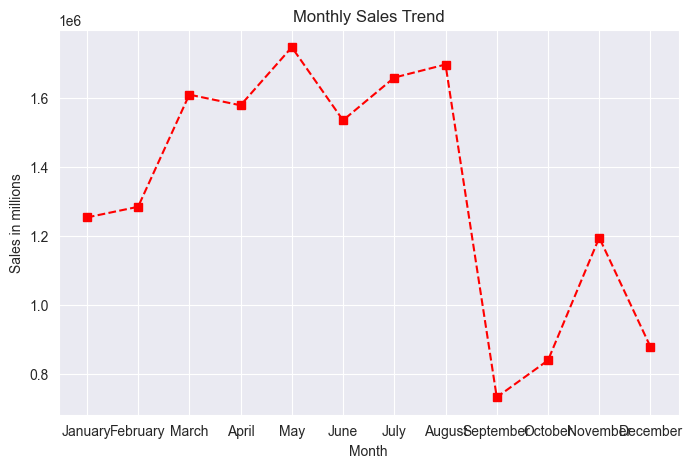

In [20]:
#plot monthly sales trend
plt.figure(figsize=(8, 5))
plt.plot(sales_df['purchase_month_name'],sales_df['payment_value'],'s--r')
plt.xlabel('Month')
plt.ylabel('Sales in millions')
plt.title('Monthly Sales Trend');

#### Business Insights
1. Sales peak in May and show a sharp drop in September, so running promotional campaigns during this period can help smooth out the revenue curve.
2. A steady growth is observed from the months of January to May, which implies that customers are the most active during the first half of the year.
3. The holiday months underperform significantly and this may be improved by introducing festive offers earlier in October.

### - Revenue by product category

In [21]:
# Merge order details with product category information
temp_df = order_items.merge(
    products[['product_id', 'product_category_name_english']], 
    on='product_id', 
    how='left'
)

# Merge order details with product category information
product_sales_df= temp_df.groupby('product_category_name_english')['price'].sum().reset_index().sort_values('price', ascending=False)
product_sales_df.rename(columns=
    {
        'product_category_name_english':'category',
        'price':'total_sales'
    }, inplace=True
)

# Select the top 10 revenue-generating product categories
top10_categories=product_sales_df.head(10)

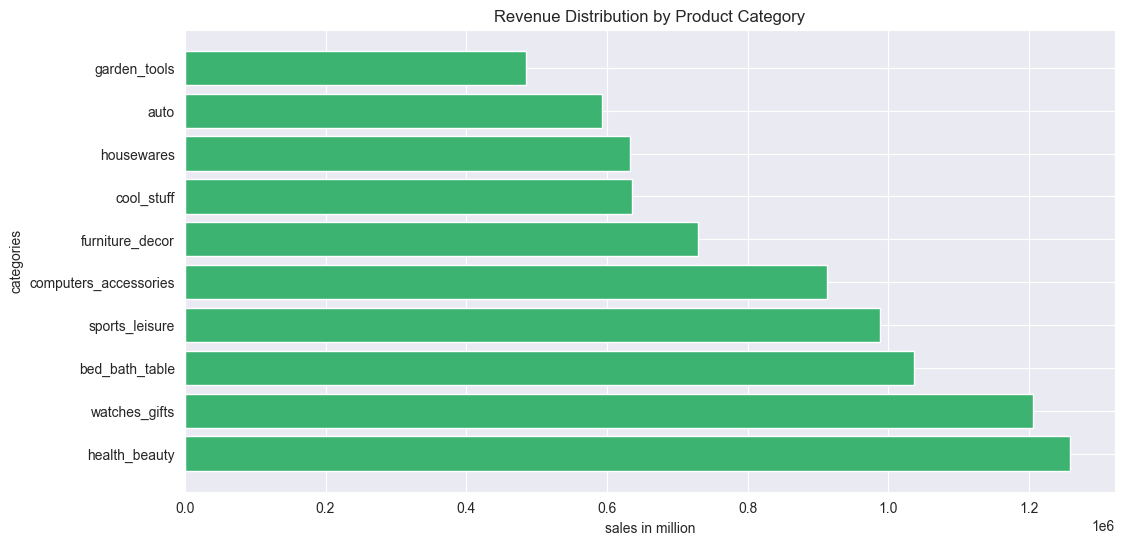

In [22]:
#Revenue Distribution by Product Category
plt.figure(figsize=(12, 6))
plt.barh(top10_categories.category, top10_categories.total_sales, color='mediumseagreen')
plt.title('Revenue Distribution by Product Category')
plt.xlabel('sales in million')
plt.ylabel('categories');

#### Business Insights
1. Health & Beauty and Watches & Gifts generate the highest revenue, making them the company's most valuable product categories.
2. Lower performing categories may benefit from targeted promotions.

### - Geographic Distribution of Orders

In [23]:
# Combine customer and order data to associate each order with a customer's state and 
#calculate the total number of orders placed in each state
state_orders=customers.merge(orders[['order_id', 'customer_id']], on='customer_id').groupby('customer_state')['order_id'].count().reset_index()

# Rename columns for better readability
state_orders.rename(
    columns={
        'customer_state':'state', 
        'order_id':'total_orders'
    }, inplace=True
)
state_orders=state_orders.sort_values('total_orders', ascending=False)

# Select the top 10 states with the highest order volumes
top10=state_orders.head(10)

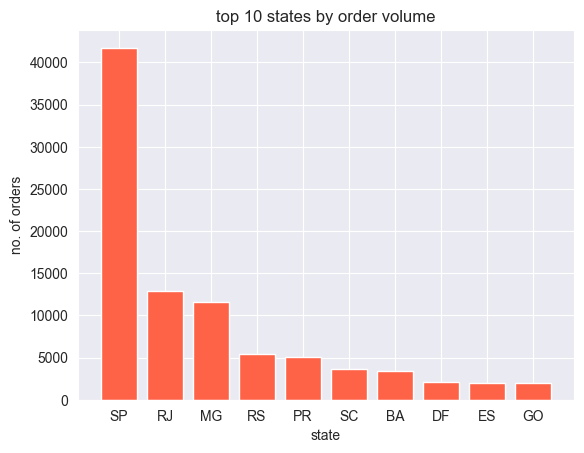

In [24]:
# Plotting top 10 states by order volume
plt.bar(top10.state, top10.total_orders, color='tomato')
plt.title('top 10 states by order volume')
plt.xlabel('state')
plt.ylabel('no. of orders');

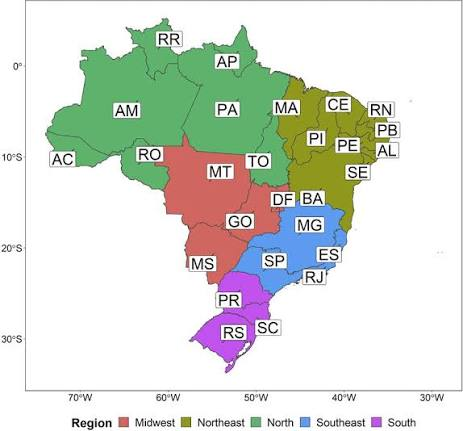

#### Business Insights
1. São Paulo accounts for the highest number of orders, making it the company's primary market.
2. Customer demand is concentrated in southeastern and southern region of Brazil.
3. There is opportunity for market expansion in the other regions.

### - Payment Method Analysis

In [25]:
# Count the number of unique orders for each payment method
payment_methods=order_payments.groupby('payment_type')['order_id'].nunique().reset_index().sort_values('order_id', ascending=False)

# Rename columns for better readability
payment_methods.rename(
    columns={
        'order_id':'total_orders'
    }, inplace=True
)

# Remove undefined payment methods to focus on valid customer transactions
payment_methods=payment_methods[payment_methods['payment_type']!='not_defined']
payment_methods

,payment_type,total_orders
1,credit_card,76505
0,boleto,19784
4,voucher,3866
2,debit_card,1528


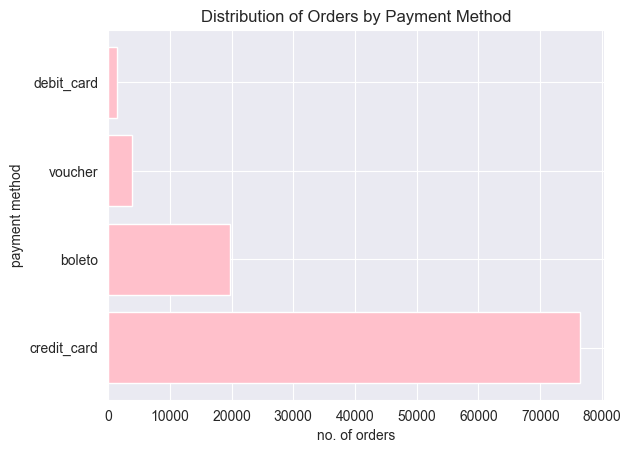

In [26]:
# Plotting the Distribution of Orders by Payment Method
plt.barh(payment_methods.payment_type, payment_methods.total_orders, color='pink')
plt.title('Distribution of Orders by Payment Method')
plt.xlabel('no. of orders')
plt.ylabel('payment method');

#### Business Insights
1. Credit cards are the dominant payment method, while alternative methods account for a small share of transactions.
2. Optimizing the checkout experience for credit card users can improve customer satisfaction.

### - Average Order Value 

In [27]:
# Calculate the total value of each order, including product price and shipping charges
order_value=order_items.copy()
order_value['total_order_value']=order_value['price']+order_value['freight_value']

# Aggregate the total value for each order
order_value=order_value.groupby('order_id')['total_order_value'].sum().reset_index()

# Compute the average order value across all orders
avg_order_value=order_value['total_order_value'].mean()
print(f'the average order value is: {avg_order_value:.2f}')

the average order value is: 160.58


### - Delivery Time Analysis

In [28]:
# Calculate the average delivery time across all completed orders
avg_delivery_days=orders['delivery_days'].mean()
print(f'On an average, delivery takes {avg_delivery_days:.2f} days')

On an average, delivery takes 12.09 days


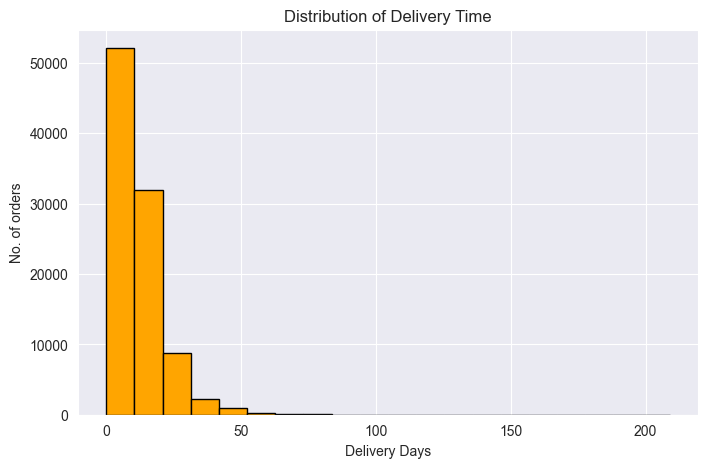

In [29]:
# Visualize the distribution of delivery times
plt.figure(figsize=(8, 5))
plt.hist(orders.delivery_days, bins=20, edgecolor='black', color='orange')
plt.ylabel('No. of orders')
plt.xlabel('Delivery Days')
plt.title('Distribution of Delivery Time');

#### Business Insights
1. Most orders are delivered within 10–20 days, indicating efficient logistics.
2. Only a small number of orders experience exceptionally long delivery times. Reducing these delivery outliers could further improve customer satisfaction.

### - Regional Delivery Performance

In [30]:
# Combine order and customer data to associate each delivery with a customer's state
df=orders.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

# Calculate the average delivery time for each state
df=df.groupby('customer_state')['delivery_days'].mean().reset_index()

# Select the states with the longest average delivery times
top10_delivery_days=df.sort_values('delivery_days').head(10)
top10_delivery_days

,customer_state,delivery_days
25,SP,8.298481
17,PR,11.527321
10,MG,11.544694
6,DF,12.509135
23,SC,14.480124
22,RS,14.819611
18,RJ,14.849510
8,GO,15.151763
11,MS,15.191155
7,ES,15.331830


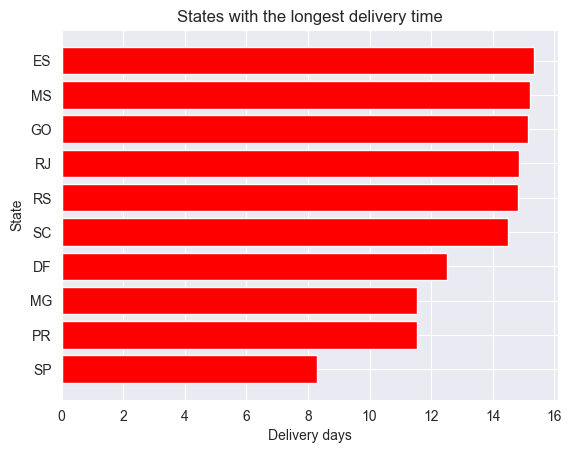

In [31]:
# Visualize the states with the highest average delivery time
plt.barh(top10_delivery_days.customer_state, top10_delivery_days.delivery_days, color='red')
plt.xlabel('Delivery days')
plt.ylabel('State')
plt.title('States with the longest delivery time');

#### Business Insights
1. Northern and northeastern states experience the longest average delivery times compared to the rest of the country. This could be the reason behind low customer demand in this region.
2. Improving the delivery logistics in these regions can help improve customer satisfaction and as a result increase customer demand.

### - Delivery Performance

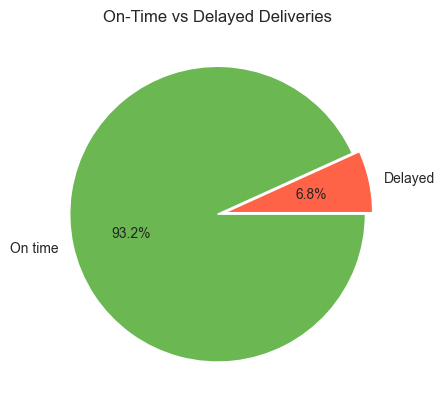

In [42]:
# Calculate the percentage of orders delivered after the estimated delivery date
delay_percentage=((orders['delivery_delay']>0).sum())*100.0/orders['delivery_delay'].count()
sizes=[delay_percentage, 100.0-delay_percentage]
colors=['tomato', '#6BB853']
labels=['Delayed', 'On time']
explode=[0.05, 0]

# Visualize the proportion of on-time and delayed deliveries
plt.pie(sizes, labels=labels, colors=colors, startangle=0, explode=explode, autopct='%1.1f%%')
plt.title('On-Time vs Delayed Deliveries');

#### Business Insights
1. Over 93% of deliveries are made on time. This demonstrates highlt reliable logistics. 

### - Impact of Delivery Delays on Customer Satisfaction

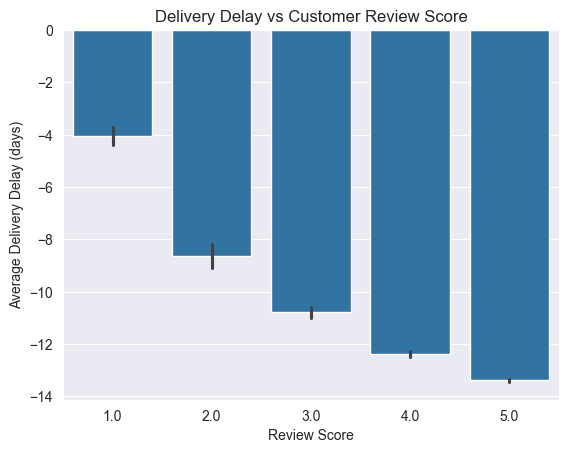

In [33]:
#Combine delivery performance data with customer review scores
review_df=orders.merge(order_reviews[['order_id', 'review_score']], on='order_id', how='left')

# Compare average delivery delay across different review scores
sns.barplot(data=review_df, x='review_score', y='delivery_delay')
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Delay (days)")
plt.title("Delivery Delay vs Customer Review Score");


#### Business Insights
1. Longer delivery delays are generally associated with lower customer review scores.
2. Reducing delivery delays can improve customer ratings and strengthen customer loyalty.

### - Customer Review Score Distribution

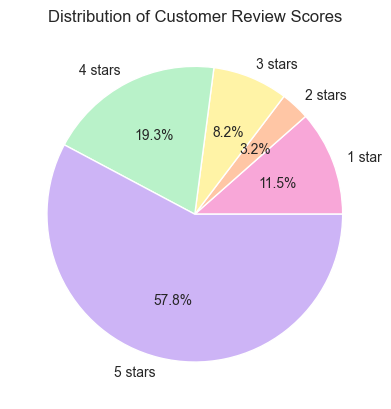

In [34]:
# Calculate the distribution of customer review scores
score_distribution=order_reviews.groupby('review_score')['order_id'].count().reset_index()

# Calculate the percentage contribution of each review score
score_distribution['percentage']=(score_distribution.order_id*100.0)/score_distribution.order_id.sum()

# Visualize the distribution of customer review scores
sizes=score_distribution.percentage.tolist()
labels=['1 star', '2 stars', '3 stars', '4 stars', '5 stars']
colors=['#f8a7d8','#ffc6a5','#fff3a6','#b9f2c9', '#cdb4f6']
plt.pie(sizes, colors=colors, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Customer Review Scores');

#### Business Insights
1. The majority of customers give 5-star ratings, indicating high customer satisfaction. 
2. Analyzing low-rated orders can help identify areas that require improvment.

### - Customer Satisfaction by Product Category

In [35]:
# Associate each order with its product category
prod_df = order_items.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')

# Create a unique order-to-category mapping
unique_prod_mappings = prod_df[['order_id', 'product_category_name_english']].drop_duplicates(subset=['order_id'])

# Merge customer reviews with product categories
prod_review = review_df.merge(unique_prod_mappings, on='order_id', how='left')

# Calculate the average review score for each product category
product_review = prod_review.groupby('product_category_name_english')['review_score'].mean().reset_index()
product_review

,product_category_name_english,review_score
0,agro_industry_and_commerce,4.021978
1,air_conditioning,4.040323
2,art,4.051020
3,arts_and_craftmanship,4.136364
4,audio,3.834302
...,...,...
66,stationery,4.254267
67,tablets_printing_image,4.173333
68,telephony,4.007940
69,toys,4.190563


In [36]:
# Select the highest and lowest rated product categories
top10_review=product_review.sort_values('review_score', ascending=False).head(10)
worst10_review=product_review.sort_values('review_score', ascending=False).tail(10)

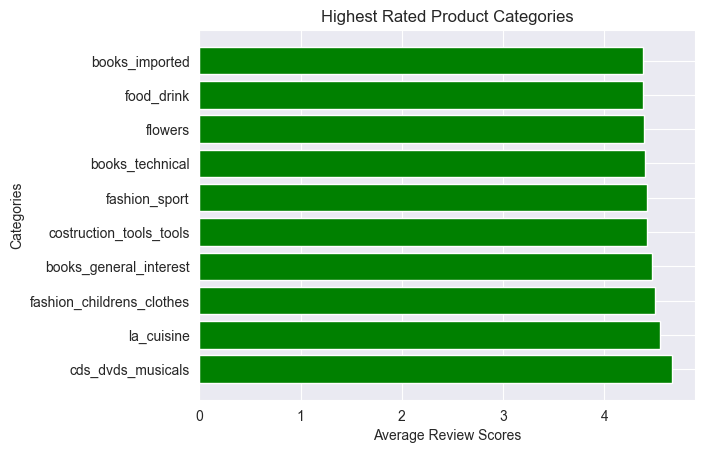

In [37]:
#Highest Rated Product Categories
plt.barh(top10_review.product_category_name_english, top10_review.review_score, color='green')
plt.xlabel('Average Review Scores')
plt.ylabel('Categories')
plt.title('Highest Rated Product Categories');

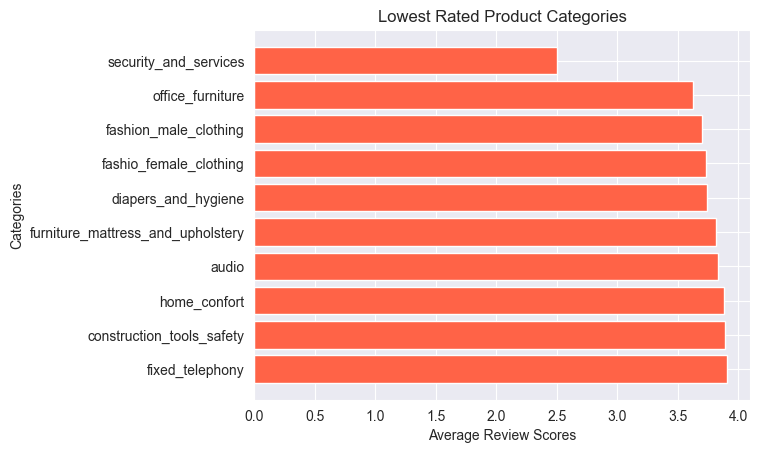

In [38]:
# Lowest Rated Product Categories
plt.barh(worst10_review.product_category_name_english, worst10_review.review_score, color='tomato')
plt.xlabel('Average Review Scores')
plt.ylabel('Categories')
plt.title('Lowest Rated Product Categories');

#### Business Insights
1. Product categories related to books, media, and fashion consistently receive the highest customer ratings, indicating that these categories are meeting or exceeding customer expectations.
2. Categories such as art, health & beauty receive comparatively lower ratings, suggesting potential issues with product quality, packaging, or delivery that require further investigation.

### - Freight Cost Analysis by Product Category


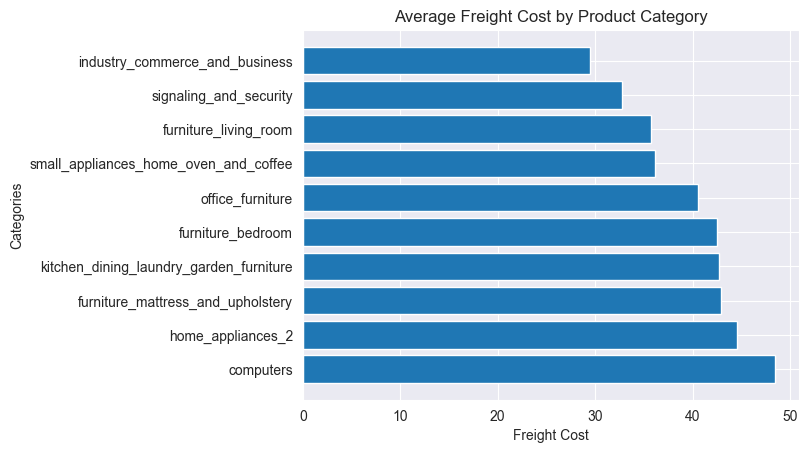

In [39]:
# Calculate the average freight cost for each product category
freight_cost=order_items.merge(products, on='product_id', how='left').groupby('product_category_name_english')['freight_value'].mean().reset_index().sort_values('freight_value', ascending=False)

# Select the top 10 product categories with the highest average freight costs
highest_freight_cost=freight_cost.head(10)

# Visualize the product categories with the highest freight costs
plt.barh(highest_freight_cost.product_category_name_english, highest_freight_cost.freight_value)
plt.xlabel('Freight Cost')
plt.ylabel('Categories')
plt.title('Average Freight Cost by Product Category');

#### Business Insights
1. Bulky product categories incur higher freight costs.
2. Improving the packaging and shipping choices can help reduce these costs

### - Revenue Contribution by State

In [40]:
# Combine customer, order, and order item data to associate revenue with each customer's state
temp=customers.merge(orders, on='customer_id', how='left')
temp_df=temp.merge(order_items, on='order_id', how='left')

# Calculate the total value of each order item, including shipping charges
temp_df['total_value']=temp_df.price+temp_df.freight_value

# Calculate the total revenue generated by each state
state_revenue=temp_df.groupby('customer_state')['total_value'].sum().reset_index()

# Rank states by total revenue
state_revenue.sort_values(by='total_value', inplace=True, ascending=False)

# Select the top 10 revenue-generating states
top10_state=state_revenue.head(10)
top10_state

,customer_state,total_value
25,SP,5921678.12
18,RJ,2129681.98
10,MG,1856161.49
22,RS,885826.76
17,PR,800935.44
4,BA,611506.67
23,SC,610213.60
6,DF,353229.44
8,GO,347706.93
7,ES,324801.91


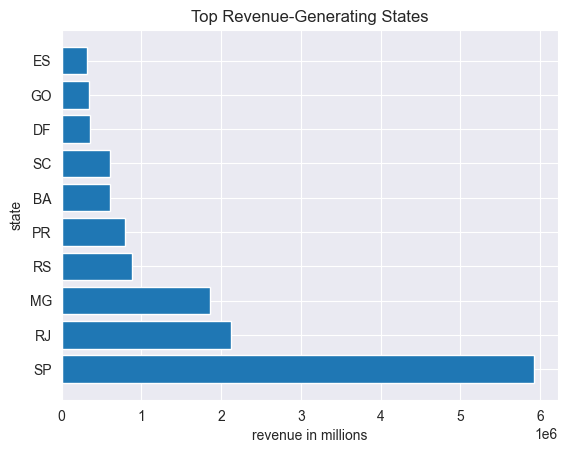

In [41]:
# Visualize the highest revenue-generating states
plt.barh(top10_state.customer_state, top10_state.total_value)
plt.xlabel('revenue in millions')
plt.ylabel('state')
plt.title('Top Revenue-Generating States');

#### Business Insights
1. São Paulo has the highest contribution to the revenue by a large margin.
2. Majority of the revenue is generated from the southern and southeastern region which directly correlates to the volume of orders placed.
3. There is a scope of expanding the market in the low-revenue states. This can aid the company's future growth.

## 7. Conclusion 
This project demonstrates how Exploratory Data Analysis (EDA) can transform raw e-commerce data into meaningful business insights. By analyzing customer purchasing pattern, product performance, regional sales, customer satisfaction, etc. we gained a comprehensive understanding of the factors influencing business performance.